# Pipeline

## Implementing the Model

In [30]:
# Making the structure simular to github in collab
import os

os.makedirs("data/processed", exist_ok=True)

In [31]:
from google.colab import files
uploaded = files.upload()

Saving borrowers.csv to borrowers.csv
Saving credit.csv to credit.csv
Saving loan_details.csv to loan_details.csv
Saving loans.csv to loans.csv


In [32]:
import shutil

files_list = ["loans.csv", "borrowers.csv", "credit.csv", "loan_details.csv"]

for f in files_list:
    shutil.move(f, f"data/processed/{f}")

In [33]:
os.listdir("data/processed")

['credit.csv', 'loans.csv', 'borrowers.csv', 'loan_details.csv']

Loading in the data

In [34]:
#Load in the data
import duckdb

con = duckdb.connect()

# Create tables from CSVs
con.execute("CREATE TABLE loans AS SELECT * FROM 'data/processed/loans.csv'")
con.execute("CREATE TABLE borrowers AS SELECT * FROM 'data/processed/borrowers.csv'")
con.execute("CREATE TABLE credit AS SELECT * FROM 'data/processed/credit.csv'")
con.execute("CREATE TABLE loan_details AS SELECT * FROM 'data/processed/loan_details.csv'")

In [35]:
# Query

df = con.execute("""
SELECT
    l.id,
    l.loan_amnt,
    l.int_rate,
    l.default_flag,
    b.annual_inc,
    c.fico_range_low,
    c.dti,
    c.revol_util   -- ADD THIS LINE
FROM loans l
JOIN borrowers b USING(id)
JOIN credit c USING(id)
""").df()

Applying low credit condition

In [36]:
# Applying low credit condition
df = con.execute("""
SELECT *
FROM (
    SELECT
        l.id,
        l.loan_amnt,
        l.int_rate,
        l.default_flag,
        b.annual_inc,
        c.fico_range_low,
        c.dti
    FROM loans l
    JOIN borrowers b USING(id)
    JOIN credit c USING(id)
)
WHERE CAST(fico_range_low AS DOUBLE) < 700
""").df()

Preparing the data

In [37]:

import pandas as pd

df = df.dropna()

df['loan_amnt'] = pd.to_numeric(df['loan_amnt'], errors='coerce')
df['int_rate'] = pd.to_numeric(df['int_rate'], errors='coerce')
df['annual_inc'] = pd.to_numeric(df['annual_inc'], errors='coerce')
df['dti'] = pd.to_numeric(df['dti'], errors='coerce')
df['fico_range_low'] = pd.to_numeric(df['fico_range_low'], errors='coerce')

df = df.dropna()

In [38]:
df.head()

,id,loan_amnt,int_rate,default_flag,annual_inc,fico_range_low,dti
0,68407277,3600.0,13.99,0,55000.0,675.0,5.91
1,68341763,20000.0,10.78,0,63000.0,695.0,10.78
2,68476807,10400.0,22.45,0,104433.0,695.0,25.37
3,68426831,11950.0,13.44,0,34000.0,690.0,10.20
4,68476668,20000.0,9.17,0,180000.0,680.0,14.67


In [39]:
# Checking if Fico score is a good indicator of default (it is not)
print(df.groupby('default_flag')['fico_range_low'].mean())

default_flag
0    675.953090
1    674.343387
Name: fico_range_low, dtype: float64


The fico score does not seem to be a good indicator as there is a small difference between a defaulted fico score vs a non defaulted one

In [40]:
# Checking how many defaults there are compared to the non defaults

df['default_flag'].value_counts()

,count
default_flag,
0,57728
1,15085


In [41]:
df['fico_range_low'] = pd.to_numeric(df['fico_range_low'], errors='coerce')

# Define low credit threshold
df_low = df[df['fico_range_low'] < 700]

Creating multiple models

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Clean data
df = df.dropna()

# Convert to numeric
cols = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low']
for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna()

# Features + Target
X = df_low[['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_low']]
y = df_low['default_flag']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# ---------------------------
# Model 1: Baseline
# ---------------------------
model_base = LogisticRegression(max_iter=1000)
model_base.fit(X_train, y_train)
y_pred_base = model_base.predict(X_test)

print("===== Baseline Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))

# ---------------------------
# Model 2: Balanced
# ---------------------------
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)
y_pred_balanced = model_balanced.predict(X_test)

print("\n===== Balanced Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

# ---------------------------
# Model 3: Random Forest
# ---------------------------
model_rf = RandomForestClassifier(n_estimators=100)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

===== Baseline Logistic Regression =====
Accuracy: 0.7935178191306737
              precision    recall  f1-score   support

           0       0.80      0.99      0.88     11578
           1       0.45      0.03      0.06      2985

    accuracy                           0.79     14563
   macro avg       0.62      0.51      0.47     14563
weighted avg       0.73      0.79      0.72     14563


===== Balanced Logistic Regression =====
Accuracy: 0.6416947057611756
              precision    recall  f1-score   support

           0       0.85      0.66      0.75     11578
           1       0.30      0.56      0.39      2985

    accuracy                           0.64     14563
   macro avg       0.58      0.61      0.57     14563
weighted avg       0.74      0.64      0.67     14563


===== Random Forest =====
Accuracy: 0.7837670809585937
              precision    recall  f1-score   support

           0       0.80      0.97      0.88     11578
           1       0.34      0.06      0

## Analysis Rationale

The objective of this analysis is to predict loan default risk specifically for borrowers with lower credit history. To align with this goal, the dataset was filtered to include only borrowers with FICO scores below 700.

Feature selection focused on variables that are both predictive and available at the time of loan approval. These include loan characteristics (loan amount, interest rate), borrower financial information (annual income, debt-to-income ratio), and credit indicators (FICO score). Variables that could introduce bias or would not be known at the time of decision-making were excluded. This ensures that the model reflects a realistic lending scenario while maintaining interpretability.

A logistic regression model was selected as a baseline due to its interpretability and common use in risk modeling. However, because loan default is a relatively rare event (approximately 20% of observations), the dataset is imbalanced. This leads to misleadingly high accuracy when using a standard model. The baseline model achieved an accuracy of approximately 79%, but a recall of only 3% for default cases, indicating that it failed to effectively identify high-risk borrowers.

To address this, a class-balanced logistic regression model was implemented to better capture default cases. This approach prioritizes recall for default predictions, which is more important in a risk context where failing to identify high-risk borrowers can have significant consequences. The balanced model improved recall for default cases to 56%, although overall accuracy decreased to approximately 64%. This tradeoff reflects a more meaningful model for risk prediction.

A random forest model was also tested to explore whether a more flexible model could improve performance. While the random forest achieved relatively high accuracy (~78%), it still performed poorly in identifying default cases, with recall remaining around 6%. These results indicate that addressing class imbalance has a greater impact on performance than increasing model complexity.


## Visualization

In [46]:
from sklearn.metrics import classification_report
import pandas as pd

# Convert reports to dictionaries
report_base = classification_report(y_test, y_pred_base, output_dict=True)
report_balanced = classification_report(y_test, y_pred_balanced, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

# Extract recall for class 1 (defaults)
recall_base = report_base['1']['recall']
recall_balanced = report_balanced['1']['recall']
recall_rf = report_rf['1']['recall']

# Put into dataframe
results_df = pd.DataFrame({
    'Model': ['Baseline', 'Balanced', 'Random Forest'],
    'Recall': [recall_base, recall_balanced, recall_rf]
})

results_df

,Model,Recall
0,Baseline,0.031826
1,Balanced,0.556114
2,Random Forest,0.057621


/tmp/ipykernel_21619/1695563270.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_rate = df_low.groupby('dti_bin')['default_flag'].mean()


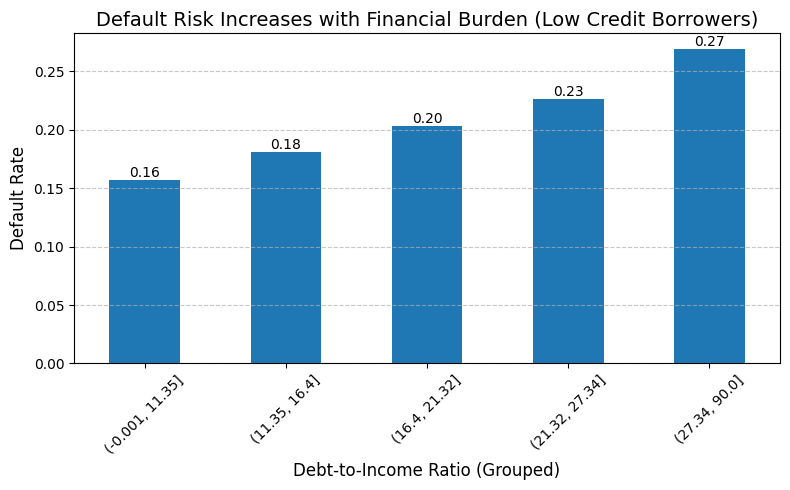

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Clean DTI
df_low['dti'] = pd.to_numeric(df_low['dti'], errors='coerce')
df_low = df_low[df_low['dti'] < 100]
df_low = df_low.dropna(subset=['dti', 'default_flag'])

# Better bins
df_low['dti_bin'] = pd.qcut(df_low['dti'], q=5)

# Default rate
default_rate = df_low.groupby('dti_bin')['default_flag'].mean()

# Plot
plt.figure(figsize=(8,5))
bars = default_rate.plot(kind='bar')

# Labels
for i, v in enumerate(default_rate):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.title("Default Risk Increases with Financial Burden (Low Credit Borrowers)", fontsize=14)
plt.xlabel("Debt-to-Income Ratio (Grouped)", fontsize=12)
plt.ylabel("Default Rate", fontsize=12)

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

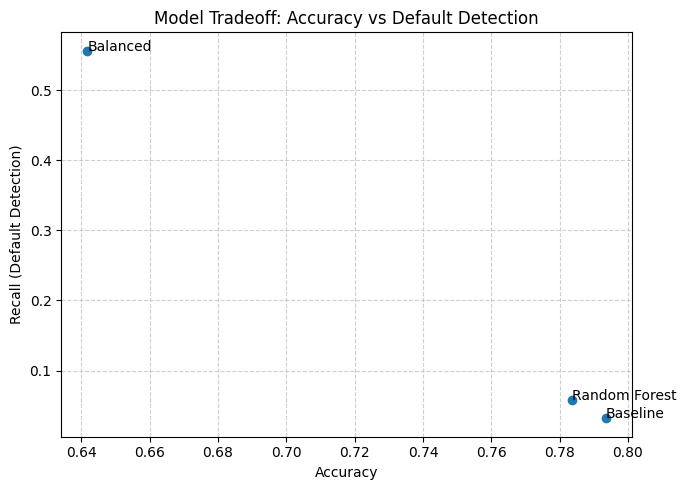

In [49]:
import matplotlib.pyplot as plt

# Extract metrics again (from your actual results)
acc_base = accuracy_score(y_test, y_pred_base)
acc_bal = accuracy_score(y_test, y_pred_balanced)
acc_rf = accuracy_score(y_test, y_pred_rf)

rec_base = classification_report(y_test, y_pred_base, output_dict=True)['1']['recall']
rec_bal = classification_report(y_test, y_pred_balanced, output_dict=True)['1']['recall']
rec_rf = classification_report(y_test, y_pred_rf, output_dict=True)['1']['recall']

models = ['Baseline', 'Balanced', 'Random Forest']
accuracy = [acc_base, acc_bal, acc_rf]
recall = [rec_base, rec_bal, rec_rf]

# Plot
plt.figure(figsize=(7,5))
plt.scatter(accuracy, recall)

# Label points
for i, model in enumerate(models):
    plt.text(accuracy[i], recall[i], model)

plt.xlabel("Accuracy")
plt.ylabel("Recall (Default Detection)")
plt.title("Model Tradeoff: Accuracy vs Default Detection")

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

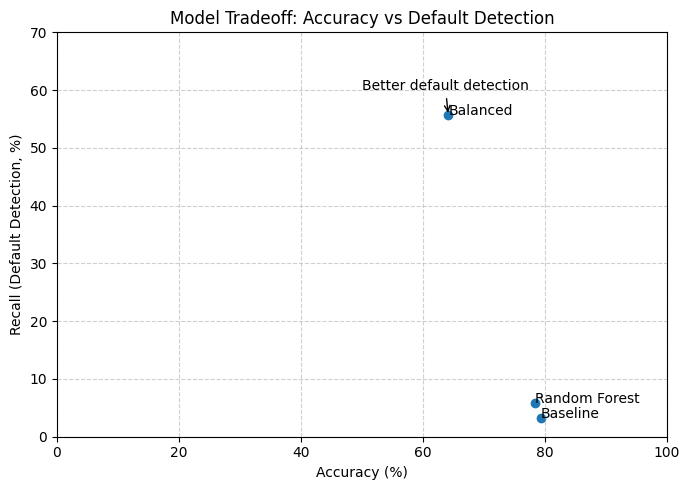

In [51]:
import matplotlib.pyplot as plt

# Convert to percentages
accuracy_pct = [a * 100 for a in accuracy]
recall_pct = [r * 100 for r in recall]

plt.figure(figsize=(7,5))
plt.scatter(accuracy_pct, recall_pct)

# Label points
for i, model in enumerate(models):
    plt.text(accuracy_pct[i], recall_pct[i], model)

plt.xlabel("Accuracy (%)")
plt.ylabel("Recall (Default Detection, %)")
plt.title("Model Tradeoff: Accuracy vs Default Detection")

plt.xlim(0, 100)   # KEY CHANGE
plt.ylim(0, 70)

plt.annotate("Better default detection",
             xy=(accuracy_pct[1], recall_pct[1]),
             xytext=(50, 60),
             arrowprops=dict(arrowstyle="->"))

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Visualization Rationale

Three visualizations were used to support data understanding and model evaluation.

The first visualization examines default rates across debt-to-income (DTI) groups within the low-credit borrower population. This chart reveals a clear upward trend, showing that borrowers with higher financial burden are more likely to default, with default rates increasing from approximately 16% in the lowest DTI group to around 27% in the highest. This provides an important data-driven explanation for why defaults occur and supports the inclusion of DTI as a key predictive feature.

The second visualization compares model performance using recall for default prediction. This highlights a critical limitation of standard models, which achieve high overall accuracy but fail to identify default cases effectively. By focusing on recall, the visualization aligns evaluation with the project’s objective of detecting high-risk borrowers.

The third visualization presents the tradeoff between accuracy and recall across models. While the baseline and random forest models achieve higher accuracy (approximately 78–80%), they perform poorly in detecting default cases, with recall below 10%. In contrast, the balanced logistic regression model achieves significantly higher recall (approximately 56%) despite a lower accuracy (around 64%). This demonstrates that the reduction in accuracy is justified, as the balanced model is far more effective at identifying high-risk borrowers. In the context of loan default prediction, failing to detect defaults is more costly than incorrectly predicting non-default cases, making recall a more appropriate metric than accuracy.

Together, these visualizations provide a cohesive narrative: financial burden drives default risk, traditional models fail to capture that risk, and adjusting for class imbalance leads to more effective and meaningful predictions.